In [3]:
import numpy as np
import matplotlib.pyplot as plt

import lightkurve as lk
import emcee
import corner

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [4]:
search_result = lk.search_lightcurve(
    "Kepler-10",
    mission="Kepler",
    cadence="long"
)

search_result


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 00,2009,Kepler,1800,kplr011904151,0.0
1,Kepler Quarter 01,2009,Kepler,1800,kplr011904151,0.0
2,Kepler Quarter 02,2009,Kepler,1800,kplr011904151,0.0
3,Kepler Quarter 03,2009,Kepler,1800,kplr011904151,0.0
4,Kepler Quarter 04,2010,Kepler,1800,kplr011904151,0.0
5,Kepler Quarter 05,2010,Kepler,1800,kplr011904151,0.0
6,Kepler Quarter 06,2010,Kepler,1800,kplr011904151,0.0
7,Kepler Quarter 07,2010,Kepler,1800,kplr011904151,0.0
8,Kepler Quarter 09,2011,Kepler,1800,kplr011904151,0.0


In [5]:
lc_collection = search_result[:10].download_all()

lc_stitched = (
    lc_collection
    .stitch()
    .remove_nans()
    .remove_outliers(sigma=5)
    .normalize()
)

lc_stitched

time,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,,,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
120.5391465105713,9.9973351e-01,4.1018640e-05,0,9.940906e-04,659.36896,250.31948,568,5.3272462e+05,2.0045162e+01,2.4877234e+03,1.3237703e+00,5.0146684e+05,2.0574972e+01,0,———,———,———,———,659.36896,3.6308160e-05,250.31948,5.3553398e-05,1.7792054e-03,3.3286733e-03
120.55958073025249,9.9962443e-01,4.1064202e-05,0,9.947103e-04,659.36919,250.31978,569,5.3274544e+05,2.0045479e+01,2.4910432e+03,1.3229831e+00,5.0141212e+05,2.0597826e+01,0,———,———,———,———,659.36919,3.6305861e-05,250.31978,5.3553318e-05,1.9566093e-03,3.5631030e-03
120.58001484981651,9.9960583e-01,4.1136471e-05,0,9.953298e-04,659.36918,250.31934,570,5.3274400e+05,2.0045910e+01,2.4830063e+03,1.3249981e+00,5.0140281e+05,2.0634075e+01,0,———,———,———,———,659.36918,3.6309517e-05,250.31934,5.3547948e-05,2.0698714e-03,3.4072644e-03
120.60044916937477,9.9951994e-01,4.1083946e-05,0,9.959494e-04,659.36967,250.31932,571,5.3266388e+05,2.0044411e+01,2.4886853e+03,1.3235550e+00,5.0135972e+05,2.0607729e+01,0,———,———,———,———,659.36967,3.6312224e-05,250.31932,5.3564647e-05,2.4259784e-03,3.0491522e-03
120.62088338893955,9.9969512e-01,4.1039806e-05,0,9.965689e-04,659.36989,250.31906,572,5.3276494e+05,2.0046177e+01,2.4869612e+03,1.3239022e+00,5.0144759e+05,2.0585588e+01,0,———,———,———,———,659.36989,3.6307927e-05,250.31906,5.3543699e-05,2.7262936e-03,3.2327282e-03
120.64131750838715,9.9964851e-01,4.1113399e-05,0,9.971884e-04,659.37001,250.31846,573,5.3270619e+05,2.0045256e+01,2.4852412e+03,1.3248761e+00,5.0142422e+05,2.0622503e+01,0,———,———,———,———,659.37001,3.6310295e-05,250.31846,5.3552700e-05,2.8024365e-03,2.5497559e-03
120.66175172782823,9.9949282e-01,4.1062165e-05,0,9.978078e-04,659.37024,250.31868,574,5.3262088e+05,2.0043943e+01,2.4874382e+03,1.3227766e+00,5.0134612e+05,2.0596804e+01,0,———,———,———,———,659.37024,3.6316073e-05,250.31868,5.3557891e-05,2.9968296e-03,2.9109719e-03
120.68218604727736,9.9953902e-01,4.1014217e-05,0,9.984273e-04,659.37011,250.31860,575,5.3262475e+05,2.0044262e+01,2.4853333e+03,1.3250123e+00,5.0136928e+05,2.0572752e+01,0,———,———,———,———,659.37011,3.6316418e-05,250.31860,5.3558793e-05,2.9321318e-03,2.7981971e-03


In [6]:
t = lc_stitched.time.value
flux = lc_stitched.flux.value

try:
    flux_err = lc_stitched.flux_err.value
    mask_err = np.isfinite(flux_err) & (flux_err > 0)

    if np.sum(mask_err) < 0.5 * len(flux_err):
        raise ValueError("flux_err no parece útil")

except:
    flux_err = np.ones_like(flux) * np.std(flux - np.median(flux))

mask = (
    np.isfinite(t)
    & np.isfinite(flux)
    & np.isfinite(flux_err)
    & (flux_err > 0)
)

t = t[mask]
flux = flux[mask]
flux_err = flux_err[mask]

print("Número de datos:", len(t))
print("Tiempo mínimo:", t.min())
print("Tiempo máximo:", t.max())
print("Flujo medio:", np.mean(flux))
print("Desviación estándar del flujo:", np.std(flux))

Número de datos: 33182
Tiempo mínimo: 120.5391465105713
Tiempo máximo: 1000.2679756718862
Flujo medio: 0.9999927
Desviación estándar del flujo: 0.0002060623


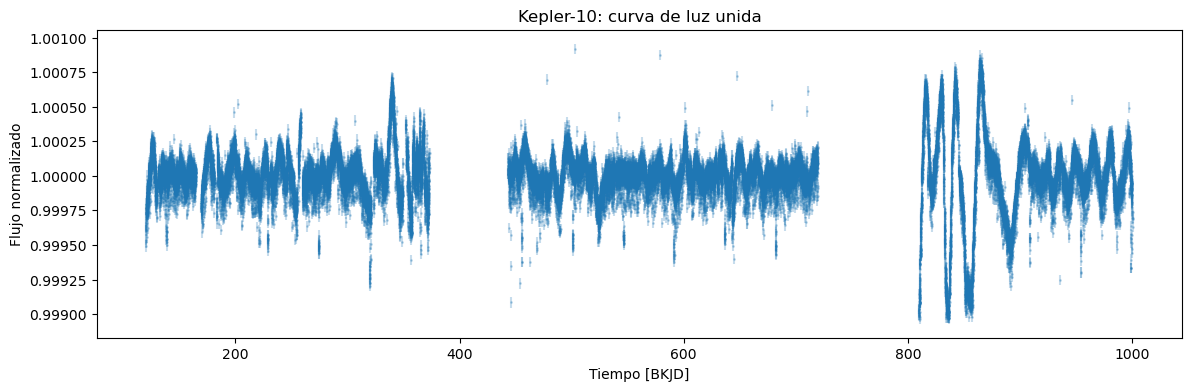

In [7]:
plt.figure(figsize=(14, 4))
plt.errorbar(
    t,
    flux,
    yerr=flux_err,
    fmt=".",
    alpha=0.25,
    markersize=2
)

plt.xlabel("Tiempo [BKJD]")
plt.ylabel("Flujo normalizado")
plt.title("Kepler-10: curva de luz unida")
plt.show()

In [8]:
def fold_time(t, P, T0):
    phase = ((t - T0 + 0.5 * P) % P) - 0.5 * P
    return phase

In [9]:
P_ref = 0.837
T0_guess = t[np.argmin(flux)]

phase = fold_time(t, P_ref, T0_guess)

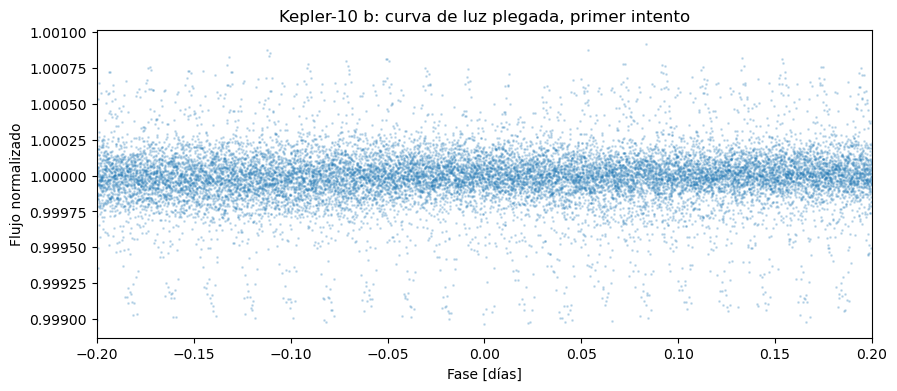

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(phase, flux, ".", alpha=0.2, markersize=2)

plt.xlabel("Fase [días]")
plt.ylabel("Flujo normalizado")
plt.title("Kepler-10 b: curva de luz plegada, primer intento")
plt.xlim(-0.2, 0.2)
plt.show()

In [11]:
def bin_data(x, y, nbins=200):
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    x_bin = np.zeros(nbins)
    y_bin = np.zeros(nbins)
    y_err = np.zeros(nbins)

    for i in range(nbins):
        mask_bin = (x >= bins[i]) & (x < bins[i + 1])

        if np.sum(mask_bin) > 0:
            x_bin[i] = np.mean(x[mask_bin])
            y_bin[i] = np.mean(y[mask_bin])
            y_err[i] = np.std(y[mask_bin]) / np.sqrt(np.sum(mask_bin))
        else:
            x_bin[i] = 0.5 * (bins[i] + bins[i + 1])
            y_bin[i] = np.nan
            y_err[i] = np.nan

    mask_good = np.isfinite(y_bin) & np.isfinite(y_err)

    return x_bin[mask_good], y_bin[mask_good], y_err[mask_good]

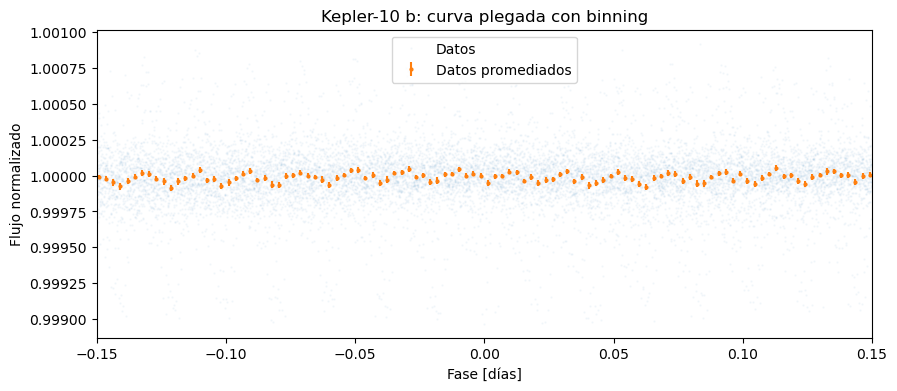

In [12]:
x_bin, y_bin, yerr_bin = bin_data(phase, flux, nbins=300)

plt.figure(figsize=(10, 4))
plt.plot(phase, flux, ".", alpha=0.06, markersize=1, label="Datos")
plt.errorbar(
    x_bin,
    y_bin,
    yerr=yerr_bin,
    fmt=".",
    markersize=4,
    label="Datos promediados"
)

plt.xlabel("Fase [días]")
plt.ylabel("Flujo normalizado")
plt.title("Kepler-10 b: curva plegada con binning")
plt.xlim(-0.15, 0.15)
plt.legend()
plt.show()

In [13]:
import os

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

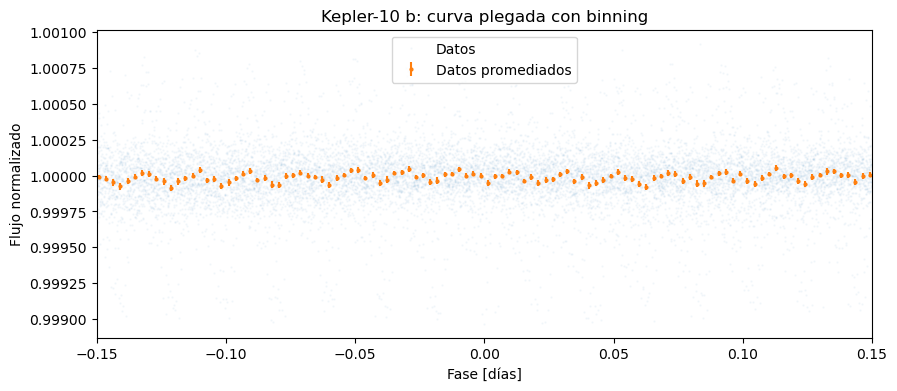

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(phase, flux, ".", alpha=0.06, markersize=1, label="Datos")
plt.errorbar(
    x_bin,
    y_bin,
    yerr=yerr_bin,
    fmt=".",
    markersize=4,
    label="Datos promediados"
)

plt.xlabel("Fase [días]")
plt.ylabel("Flujo normalizado")
plt.title("Kepler-10 b: curva plegada con binning")
plt.xlim(-0.15, 0.15)
plt.legend()

plt.savefig("figures/kepler10b_curva_plegada.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
P_ref = 0.8374907  # periodo más preciso aproximado de Kepler-10 b

def fold_time(t, P, T0):
    return ((t - T0 + 0.5 * P) % P) - 0.5 * P

def transit_score(T0, t, flux, P, width=0.06):
    phase = fold_time(t, P, T0)

    in_transit = np.abs(phase) < width / 2
    out_transit = (np.abs(phase) > 0.10) & (np.abs(phase) < 0.30)

    if np.sum(in_transit) < 10 or np.sum(out_transit) < 10:
        return np.inf

    return np.mean(flux[in_transit]) - np.mean(flux[out_transit])

In [16]:
T0_grid = np.linspace(t.min(), t.min() + P_ref, 500)

scores = np.array([
    transit_score(T0, t, flux, P_ref, width=0.06)
    for T0 in T0_grid
])

T0_best_initial = T0_grid[np.argmin(scores)]

print("T0 inicial mejorado =", T0_best_initial)
print("Score mínimo =", np.min(scores))

T0 inicial mejorado = 120.68516192319655
Score mínimo = -0.00017166138


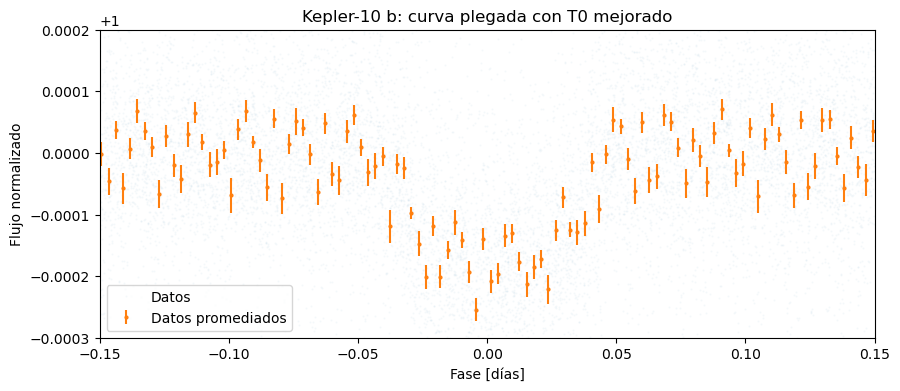

In [17]:
phase = fold_time(t, P_ref, T0_best_initial)

x_bin, y_bin, yerr_bin = bin_data(phase, flux, nbins=300)

plt.figure(figsize=(10, 4))
plt.plot(phase, flux, ".", alpha=0.04, markersize=1, label="Datos")
plt.errorbar(
    x_bin,
    y_bin,
    yerr=yerr_bin,
    fmt=".",
    markersize=4,
    label="Datos promediados"
)

plt.xlabel("Fase [días]")
plt.ylabel("Flujo normalizado")
plt.title("Kepler-10 b: curva plegada con T0 mejorado")
plt.xlim(-0.15, 0.15)
plt.ylim(0.9997, 1.0002)
plt.legend()
plt.show()

In [18]:
# Nos quedamos solo con una ventana alrededor del tránsito
mask_fit = (x_bin > -0.12) & (x_bin < 0.12)

x_fit = x_bin[mask_fit]
y_fit = y_bin[mask_fit]
yerr_fit = yerr_bin[mask_fit]

print("Número de puntos binned usados en el ajuste:", len(x_fit))

Número de puntos binned usados en el ajuste: 86


In [19]:
def box_model_phase(x, Tc, delta, Tdur, F0):
    in_transit = np.abs(x - Tc) < 0.5 * Tdur

    model = np.ones_like(x) * F0
    model[in_transit] -= delta

    return model

In [20]:
def log_prior(theta):
    Tc, delta, Tdur, F0, sigma = theta

    if not (-0.03 < Tc < 0.03):
        return -np.inf

    if not (0.0 < delta < 8e-4):
        return -np.inf

    if not (0.01 < Tdur < 0.12):
        return -np.inf

    if not (0.9998 < F0 < 1.0002):
        return -np.inf

    if not (1e-8 < sigma < 1e-3):
        return -np.inf

    return 0.0

In [21]:
def log_likelihood(theta, x, y, yerr):
    Tc, delta, Tdur, F0, sigma = theta

    model = box_model_phase(x, Tc, delta, Tdur, F0)

    s2 = yerr**2 + sigma**2

    return -0.5 * np.sum((y - model)**2 / s2 + np.log(2 * np.pi * s2))

In [22]:
def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, x, y, yerr)

In [23]:
initial = np.array([
    0.0,       # Tc
    2e-4,      # delta
    0.07,      # Tdur
    1.0,       # F0
    2e-5       # sigma
])

ndim = len(initial)
nwalkers = 40

rng = np.random.default_rng(123)

pos = initial + rng.normal(
    scale=[2e-3, 3e-5, 5e-3, 2e-5, 5e-6],
    size=(nwalkers, ndim)
)

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_probability,
    args=(x_fit, y_fit, yerr_fit)
)

sampler.run_mcmc(pos, 4000, progress=True)

100%|█████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:09<00:00, 409.59it/s]


State([[3.39349844e-03 1.28684559e-04 7.02180801e-02 9.99996545e-01
  3.87811085e-05]
 [3.76507284e-03 1.66576042e-04 6.86445009e-02 9.99994306e-01
  4.41249151e-05]
 [4.10734645e-03 1.55477537e-04 7.03113916e-02 9.99999177e-01
  3.63285449e-05]
 [4.36668879e-03 1.78936486e-04 7.08021198e-02 1.00000473e+00
  4.03297727e-05]
 [3.75938220e-03 1.64458061e-04 6.69731605e-02 9.99992335e-01
  3.91212517e-05]
 [3.53216708e-03 1.60558761e-04 6.94462504e-02 9.99997657e-01
  4.27878936e-05]
 [5.74961604e-03 1.54085159e-04 6.62133638e-02 9.99994272e-01
  4.23949589e-05]
 [4.01300903e-03 1.65581333e-04 6.98525484e-02 1.00000809e+00
  3.72464054e-05]
 [1.95445333e-03 1.71543999e-04 6.63110861e-02 1.00000267e+00
  4.41396330e-05]
 [4.12765375e-03 1.54310393e-04 6.79141479e-02 1.00000171e+00
  4.33720516e-05]
 [3.54955020e-03 1.76386729e-04 7.03034754e-02 1.00000466e+00
  4.06225097e-05]
 [4.04985300e-03 1.54718434e-04 6.79675856e-02 9.99997059e-01
  3.93544422e-05]
 [4.74200249e-03 1.62643385e-04 6.

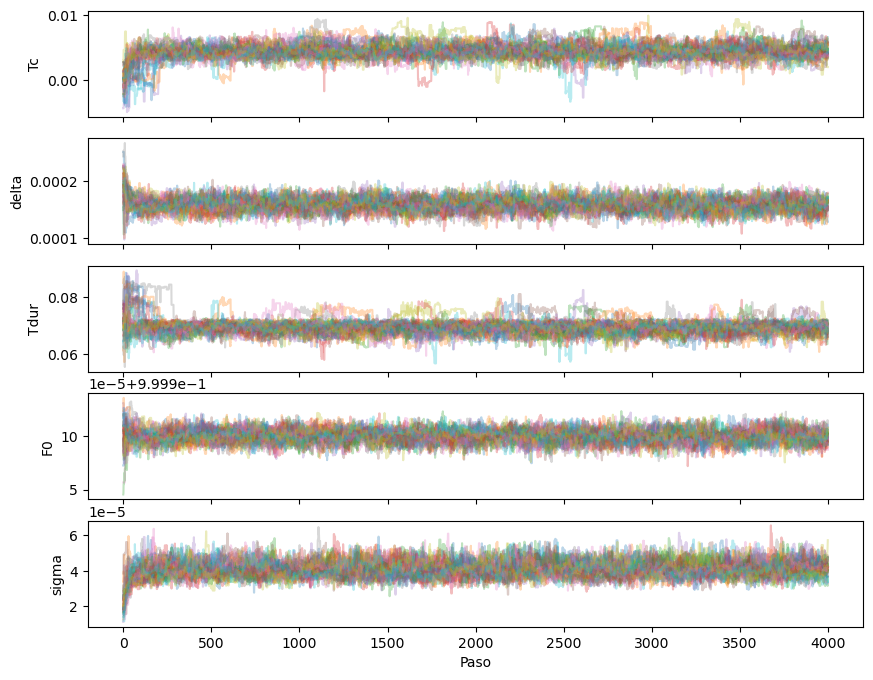

In [24]:
labels = ["Tc", "delta", "Tdur", "F0", "sigma"]

samples_chain = sampler.get_chain()

fig, axes = plt.subplots(ndim, figsize=(10, 8), sharex=True)

for i in range(ndim):
    axes[i].plot(samples_chain[:, :, i], alpha=0.3)
    axes[i].set_ylabel(labels[i])

axes[-1].set_xlabel("Paso")
plt.show()

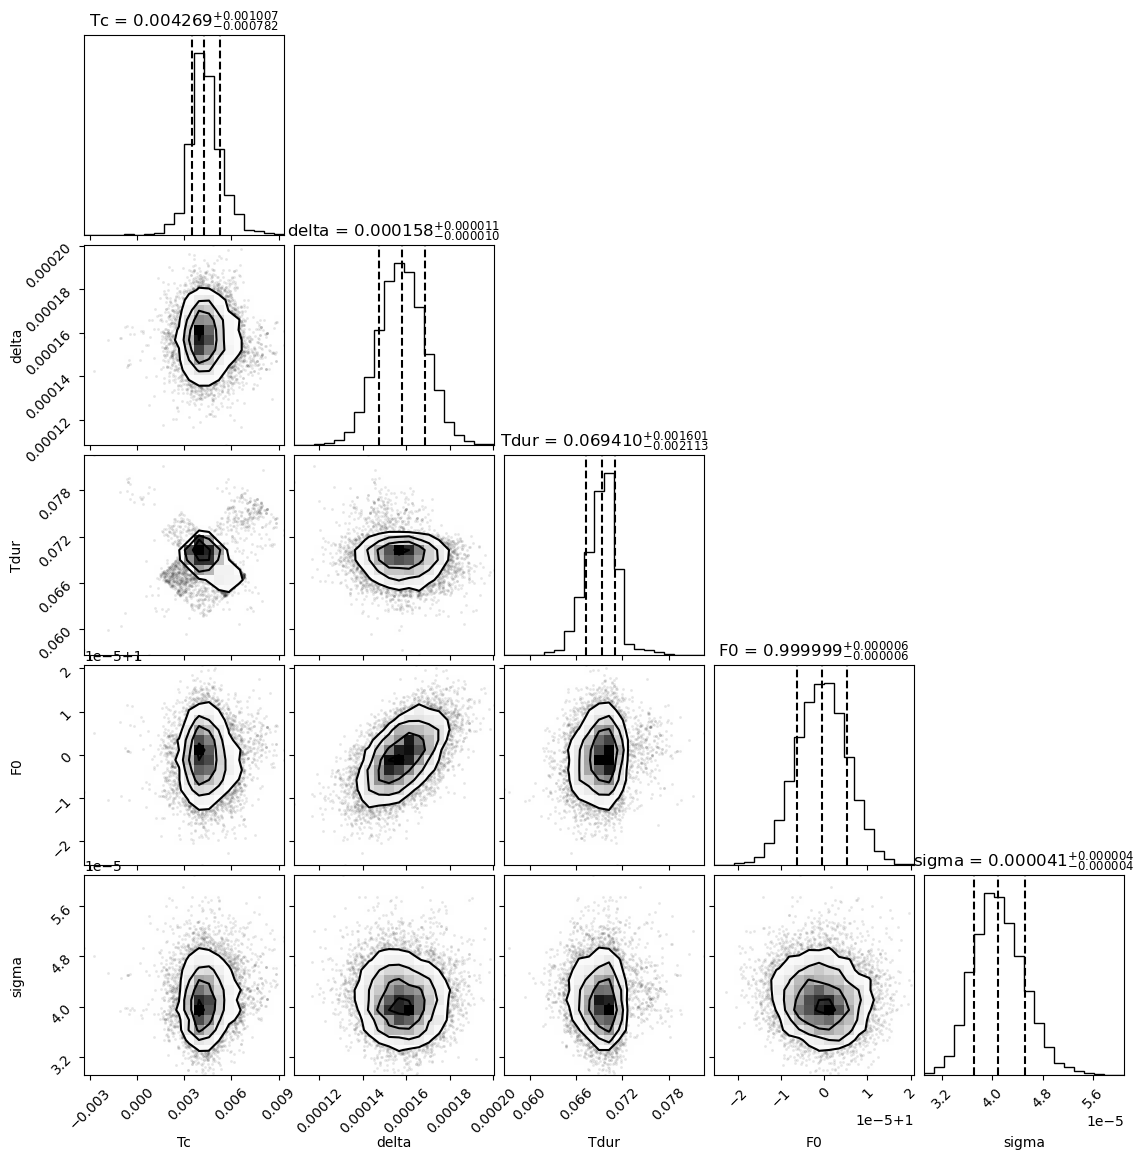

In [25]:
flat_samples = sampler.get_chain(discard=1500, thin=10, flat=True)

fig = corner.corner(
    flat_samples,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".6f"
)

plt.show()

In [26]:
best_values = []

for i, label in enumerate(labels):
    q16, q50, q84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    best_values.append(q50)
    print(f"{label} = {q50:.8f} +{q84-q50:.8f} -{q50-q16:.8f}")

Tc = 0.00426910 +0.00100654 -0.00078236
delta = 0.00015788 +0.00001076 -0.00001050
Tdur = 0.06940970 +0.00160120 -0.00211270
F0 = 0.99999949 +0.00000586 -0.00000588
sigma = 0.00004088 +0.00000427 -0.00000380


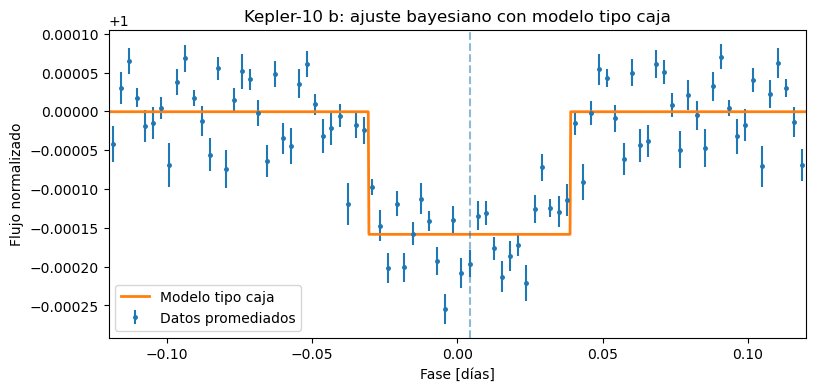

In [27]:
Tc_best, delta_best, Tdur_best, F0_best, sigma_best = np.median(flat_samples, axis=0)

x_model = np.linspace(-0.12, 0.12, 1000)
y_model = box_model_phase(x_model, Tc_best, delta_best, Tdur_best, F0_best)

plt.figure(figsize=(9, 4))

plt.errorbar(
    x_fit,
    y_fit,
    yerr=yerr_fit,
    fmt=".",
    markersize=5,
    label="Datos promediados"
)

plt.plot(
    x_model,
    y_model,
    lw=2,
    label="Modelo tipo caja"
)

plt.axvline(Tc_best, linestyle="--", alpha=0.5)

plt.xlabel("Fase [días]")
plt.ylabel("Flujo normalizado")
plt.title("Kepler-10 b: ajuste bayesiano con modelo tipo caja")
plt.xlim(-0.12, 0.12)
plt.legend()
plt.show()

In [28]:
Rp_Rs_best = np.sqrt(delta_best)

print("Profundidad delta =", delta_best)
print("Rp/Rs aproximado =", Rp_Rs_best)

Profundidad delta = 0.00015788339998156205
Rp/Rs aproximado = 0.012565166134260305


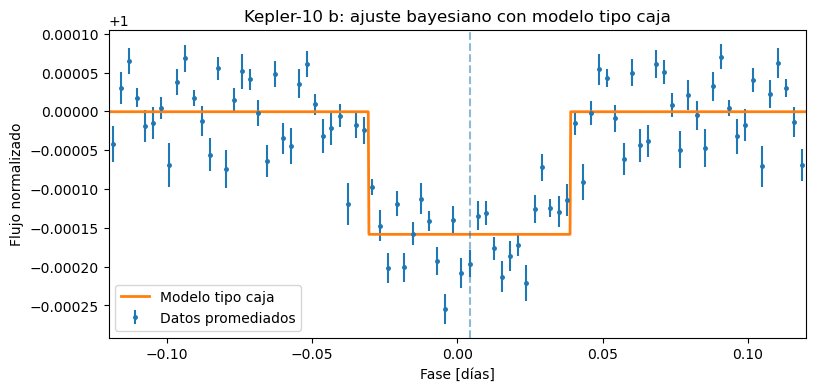

In [29]:
plt.figure(figsize=(9, 4))

plt.errorbar(
    x_fit,
    y_fit,
    yerr=yerr_fit,
    fmt=".",
    markersize=5,
    label="Datos promediados"
)

plt.plot(
    x_model,
    y_model,
    lw=2,
    label="Modelo tipo caja"
)

plt.axvline(Tc_best, linestyle="--", alpha=0.5)

plt.xlabel("Fase [días]")
plt.ylabel("Flujo normalizado")
plt.title("Kepler-10 b: ajuste bayesiano con modelo tipo caja")
plt.xlim(-0.12, 0.12)
plt.legend()

plt.savefig("figures/kepler10b_ajuste_caja_emcee.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
import numpy as np
import os

os.makedirs("results", exist_ok=True)

resultados = np.array([
    Tc_best,
    delta_best,
    Tdur_best,
    F0_best,
    sigma_best,
    Rp_Rs_best
])

np.savetxt(
    "results/kepler10b_resultados_caja.txt",
    resultados,
    header="Tc delta Tdur F0 sigma Rp_Rs"
)

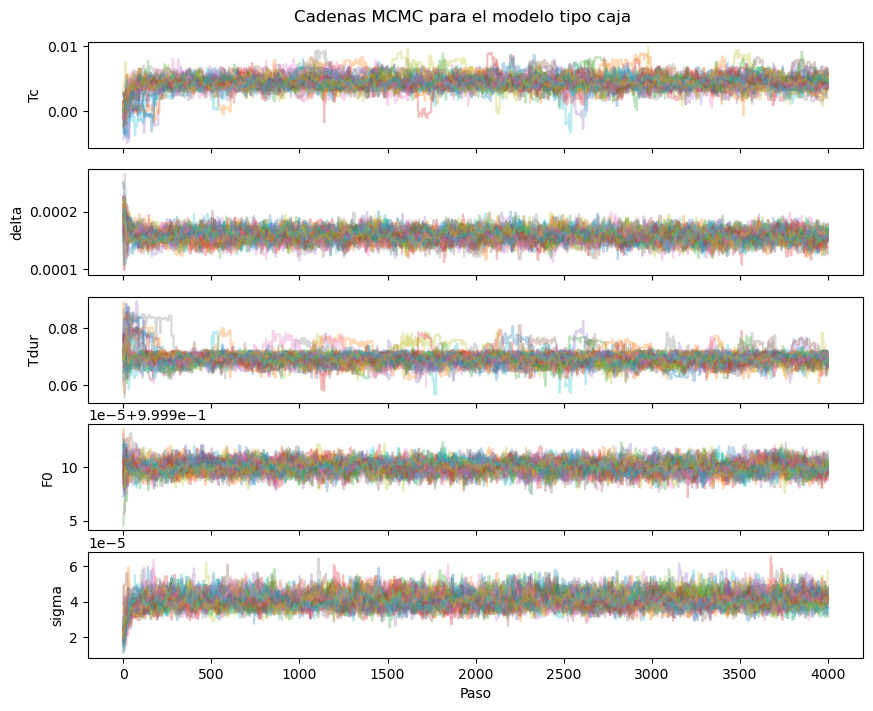

In [31]:
labels = ["Tc", "delta", "Tdur", "F0", "sigma"]

samples_chain = sampler.get_chain()

fig, axes = plt.subplots(ndim, figsize=(10, 8), sharex=True)

for i in range(ndim):
    axes[i].plot(samples_chain[:, :, i], alpha=0.3)
    axes[i].set_ylabel(labels[i])

axes[-1].set_xlabel("Paso")

fig.suptitle("Cadenas MCMC para el modelo tipo caja", y=0.92)

plt.savefig(
    "figures/kepler10b_cadenas_mcmc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

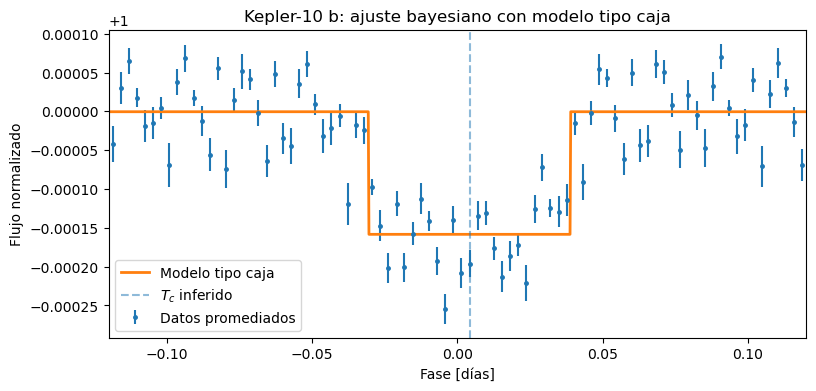

In [32]:
Tc_best, delta_best, Tdur_best, F0_best, sigma_best = np.median(flat_samples, axis=0)

x_model = np.linspace(-0.12, 0.12, 1000)
y_model = box_model_phase(x_model, Tc_best, delta_best, Tdur_best, F0_best)

plt.figure(figsize=(9, 4))

plt.errorbar(
    x_fit,
    y_fit,
    yerr=yerr_fit,
    fmt=".",
    markersize=5,
    label="Datos promediados"
)

plt.plot(
    x_model,
    y_model,
    lw=2,
    label="Modelo tipo caja"
)

plt.axvline(Tc_best, linestyle="--", alpha=0.5, label=r"$T_c$ inferido")

plt.xlabel("Fase [días]")
plt.ylabel("Flujo normalizado")
plt.title("Kepler-10 b: ajuste bayesiano con modelo tipo caja")
plt.xlim(-0.12, 0.12)
plt.legend()

plt.savefig(
    "figures/kepler10b_ajuste_modelo_caja.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()